# Chapter 3 (part 1) — A/B Testing, Resampling, Significance, and t-Tests

Covers the first half of Ch 3 of *Practical Statistics for Data Scientists*: A/B Testing and Hypothesis Tests → Resampling (Permutation Tests) → Statistical Significance and P-Values → t-Tests, applied to the Ames Housing dataset.

These four build on each other in order — section 2 reuses the groups you set up in section 1, section 3 reuses the simulation from section 2, and section 4 revisits the same comparison with a different tool. Ask for a hint if you get stuck; per the repo's review protocol, the first couple of asks per question get a nudge, not the answer.

Primary tools: pandas / numpy for data wrangling, scipy.stats for the formal tests.

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

ames = pd.read_csv('../data/ames_housing.csv')
ames.shape

(2930, 81)

In [21]:
ames.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,Typical,CBlock,Typical,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,Typical,7,Typ,2,Good,Attchd,Fin,2,528,Typical,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,Typical,CBlock,Typical,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,Typical,5,Typ,0,No_Fireplace,Attchd,Unf,1,730,Typical,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Good,6,Typ,0,No_Fireplace,Attchd,Unf,1,312,Typical,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Good,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0,Good,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Excellent,8,Typ,2,Typical,Attchd,Fin,2,522,Typical,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,Typical,PConc,Good,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,Typical,6,Typ,1,Typical,Attchd,Fin,2,482,Typical,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


In [22]:
ames["Overall_Qual"].value_counts()

Overall_Qual
Average           825
Above_Average     732
Good              602
Very_Good         350
Below_Average     226
Excellent         107
Fair               40
Very_Excellent     31
Poor               13
Very_Poor           4
Name: count, dtype: int64

## 1. A/B Testing and Hypothesis Tests

Pick two groups within Ames and ask a very ordinary question: *is there an actual difference between these two groups, or does it just look that way because of which houses happened to land in my data?* That's the whole idea behind a hypothesis test. Before touching any test statistic, you write down two competing stories:

- **Null hypothesis (H0):** "no real difference — whatever gap I see between the groups is just noise from random sampling."
- **Alternative hypothesis (H1):** "there IS a real difference."

You also have to decide, before looking at results, whether you care about a difference in one specific direction ("group A is higher than group B" — a *one-sided* test) or any difference at all, in either direction ("group A and group B differ" — a *two-sided* test).

1. Pick a binary grouping variable in Ames (e.g. `Central_Air` Y/N, two `Bldg_Type` categories, or `Overall_Qual >= 7` vs. not) and a numeric outcome (e.g. `Sale_Price`). Write out, in your own words, the null and alternative hypothesis for whether these two groups differ in average `Sale_Price`.
2. Decide: is your alternative hypothesis one-sided or two-sided, and why does that choice matter for how you'd interpret a result later?
3. Compute the actual observed difference in group means. That single number is what the rest of this notebook is about explaining.

In [23]:
# Decide on your two groups: Do houses with above average quality have meaningfully higher price than houses with average quality
groups = ames[(ames["Overall_Qual"] == "Average") | (ames["Overall_Qual"] == "Above_Average")]

* Null Hypothesis: There is no real difference in price between the 2 housing quality groups.
* Alternate hypothesis: Houses with above average quality have meaningfully higher prices than average quality houses
* Alternate hypothsis is one sided because it is not measuring if theres a difference but more specifically if above average houses have HIGHER prices than average houses. It is important because it'll decide if you will conduct a one way or two way hypothesis test

In [24]:
# Find the observed difference in group means
grouped_data = pd.DataFrame(groups.groupby("Overall_Qual")["Sale_Price"].mean().reset_index())
obs_difference = int(abs(grouped_data["Sale_Price"].diff()).iloc[1])

* The observed difference between the 2 groups is an average of 27377.801942. This would indicate that on average, above average houses cost $27377.80 more in sales price

**Your notes (bullet points):**

- 

## 2. Resampling (Permutation Test)

Here's the trick: if the null hypothesis is right — group labels don't actually matter — then randomly reshuffling which houses get which label shouldn't change much. So: pool all the values from both of your groups together, shuffle the group labels randomly, split back into two groups of the *same sizes* as your originals, and compute the difference in means again. Do that thousands of times. You've just built a picture of what differences "random noise alone" can produce when there's truly no effect. Then compare: does your real, non-shuffled difference look like a typical value from that pile of random shuffles, or does it stand out?

1. Implement the permutation test: shuffle the combined values/labels, recompute the group-mean difference, repeat several thousand times, and collect the results into an array.
2. Plot a histogram of your shuffled differences (this is called the *null distribution*), and mark where your real observed difference (from section 1) falls on it.
3. Does your real difference look like an unremarkable draw from that pile, or does it sit out in the tail?

In [25]:


def permutation_test(iterations, df):
    # create a column wit h binary 0,1 
    df["rand_group_label"] = np.random.randint(0,2, size = len(df))
    differences = []

    # both sizes
    size_above_avg = len(df[df["Overall_Qual"] == "Above_Average"])
    size_avg = len(df) - size_above_avg
    print(f"Size of Above Average Group {size_above_avg}")
    print(f"Size of Average Group {size_avg}")

    for i in range(0,iterations):
        # first shuffle (size abv avg)
        group_1 = df.sample(size_above_avg, replace=False)
        group_1_estimate = group_1["Sale_Price"].mean()
        # second shuffle (size avg)
        group_2 = df[~df.index.isin(group_1.index)]
        group_2_estimate = group_2["Sale_Price"].mean()

        # compute the difference and append to list of differences
        # no abs becuase we want both directions 
        iter_difference = group_1_estimate - group_2_estimate
        differences.append(iter_difference)

        # print results

    print(f"The range of differences of the permutation test ranges from {min(differences)} to {max(differences)}")

    return differences



In [26]:
# call the function with 1000 iterations
differences = permutation_test(10000, groups)

Size of Above Average Group 732
Size of Average Group 825
The range of differences of the permutation test ranges from -6754.670069547923 to 7698.49246398409


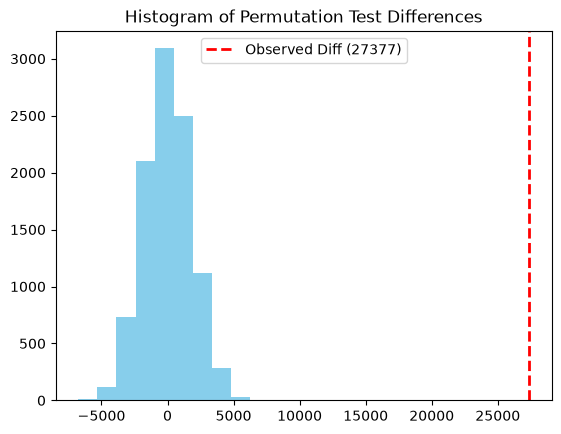

In [27]:
# plot the difference
plt.hist(differences, color = "skyblue")
plt.title("Histogram of Permutation Test Differences")
plt.axvline(x=obs_difference, color='red', linestyle='--', linewidth=2, 
            label=f'Observed Diff ({obs_difference})')

plt.legend()
plt.show()

* Our observed difference is an unlikely outcome under random chance from the results of our 1000 permutations. What this means is that, of our 1000 draws, it is unlikely that the results of our observed difference is within the realm produced by chance.

* Sections 1 + 2 show us how we can build more trust in the estimates we observe from a sample. 
* Our 2 groups were houses with overall qualities of average and above average.
* The observed gap between the average sale price of the houses with these quality ratings was $27377.
* The permutation test showed us that, based on 1000 iterations, random chance alone is able to produce sale price differences ranging from -5544.78 to 7379.36.

## 3. Statistical Significance and P-Values

The p-value puts a number on what you just did visually in section 2: out of all those random shuffles, what fraction produced a difference at least as extreme as your real one? A small fraction means your real result looks unusual if the null hypothesis were true — evidence against "no real difference." `alpha` is a threshold you commit to *ahead of time* (commonly 0.05) for how small is small enough to call "surprising."

Two ways this kind of decision can go wrong, precisely because you're judging under uncertainty:
- **Type 1 error:** you reject the null (declare a real difference) when there actually isn't one — a false alarm.
- **Type 2 error:** you fail to reject the null (declare "no evidence") when there actually IS a real difference — a missed effect.

1. Compute the p-value from your permutation test: what fraction of shuffled differences were at least as extreme as the observed one? (Think carefully about whether "extreme" means one direction or both, based on your section-1 answer about one-sided vs. two-sided.)
2. Compare it to `alpha = 0.05`. What's your conclusion?
3. In your own words (no code needed): describe what a Type 1 error and a Type 2 error would concretely look like for your specific Ames comparison — what real-world mistake would each one represent?

In [28]:
# estimate p-value from permutation test

p_value = round(len([x for x in differences if x >= obs_difference]) / len(differences),4)
alpha = 0.05

if p_value < alpha:
    print(f"Observed difference is statistically signficant with a p-value of {p_value}.")
else:
    print(f"Observed difference is NOT statistically signficant with a p-value of {p_value}.")

Observed difference is statistically signficant with a p-value of 0.0.


* Within all of the iterations, 0 contain differences greater than or equal to the one we observed. That is why our p-value is 0.0.
* Note that we are using the entire "population" of above_average and average houses in the sample. So remember that as sample size increases, interval width decreases.
* Becuase our sample size is essentially all of the houses that meet our condition, the interval width is as tight as it can be.
* If we took our original data, took a smaller chunk of that, and recalculated p-value we may get a different result.

Size of Above Average Group 290
Size of Average Group 333
The range of differences of the permutation test ranges from -11543.20646163405 to 11141.496375686023


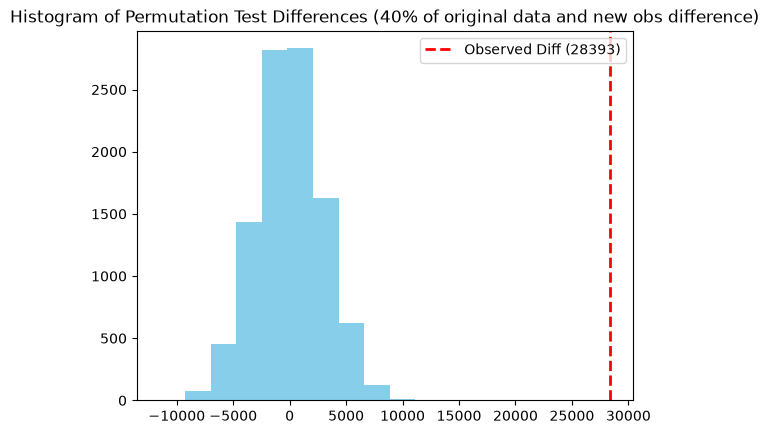

Observed difference is statistically signficant with a p-value of 0.0.


In [29]:
smaller_sample = groups.sample(frac = 0.4)

# new observed difference
grouped_data = pd.DataFrame(smaller_sample.groupby("Overall_Qual")["Sale_Price"].mean().reset_index())
new_obs_diff = int(abs(grouped_data["Sale_Price"].diff()).iloc[1])

# perm test
smaller_sample_difference = permutation_test(10000, smaller_sample)

# plot the difference
plt.hist(smaller_sample_difference, color = "skyblue")
plt.title("Histogram of Permutation Test Differences (40% of original data and new obs difference)")
plt.axvline(x=new_obs_diff, color='red', linestyle='--', linewidth=2, 
            label=f'Observed Diff ({new_obs_diff})')

plt.legend()
plt.show()

# estimate p-value from NEW permutation test

p_value = round(len([x for x in smaller_sample_difference if x >= new_obs_diff]) / len(smaller_sample_difference),4)
alpha = 0.05

if p_value < alpha:
    print(f"Observed difference is statistically signficant with a p-value of {p_value}.")
else:
    print(f"Observed difference is NOT statistically signficant with a p-value of {p_value}.")

## 4. t-Tests

Permutation tests work by brute-force simulation — flexible, but you're generating thousands of fake datasets by hand. A t-test is a shortcut: if the data in each group is roughly normal, the standardized difference between two group means follows a known, well-studied shape (the t-distribution) without needing to simulate anything. Same question as sections 1-3, different tool for answering it.

1. Run `scipy.stats.ttest_ind` on your two groups. How does its p-value compare to the one you got from your permutation test?
2. `ttest_ind` defaults to assuming equal variance between the two groups (`equal_var=True`, the classic Student's t-test); setting `equal_var=False` switches to Welch's t-test, which doesn't assume that. Check: do your two groups actually look like they have similar variance? Which version is more appropriate here?
3. The t-test assumes roughly normal data within each group — eyeball this with a histogram or QQ-plot for each group. Does the assumption look reasonable, and if it's shaky, does that change how much you'd trust the t-test's p-value versus the permutation test's?

In [30]:
above_avg = groups[groups["Overall_Qual"] == "Above_Average"]
avg = groups[groups["Overall_Qual"] == "Average"]

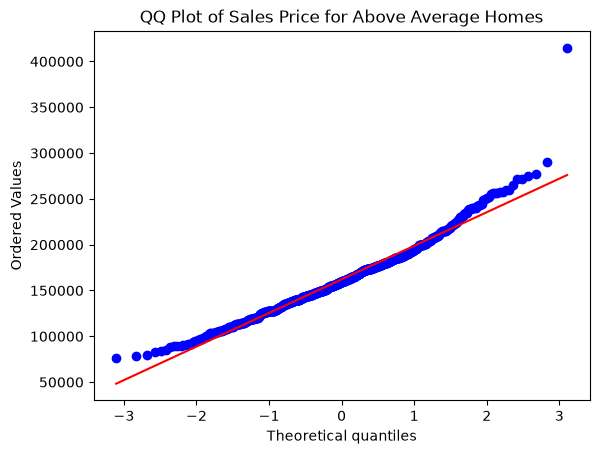

1383936454.6222088


In [ ]:
# qq plot
stats.probplot(above_avg["Sale_Price"], dist="norm", plot=plt)
plt.title("QQ Plot of Sales Price for Above Average Homes")
plt.show()


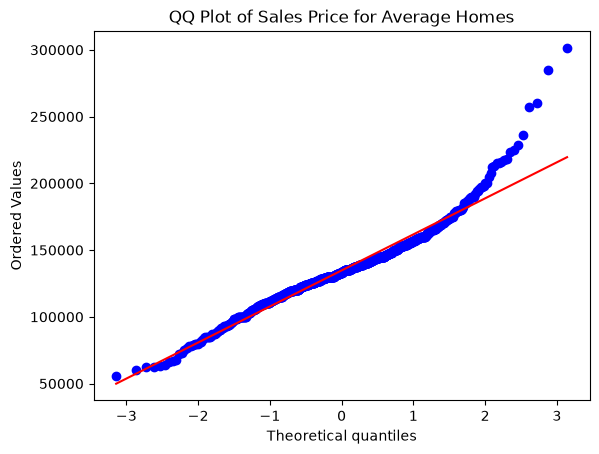

766769143.0679964


In [ ]:
# qq plot
stats.probplot(avg["Sale_Price"], dist="norm", plot=plt)
plt.title("QQ Plot of Sales Price for Average Homes")
plt.show()


In [39]:
# Calculate individual variances
var_above = np.var(above_avg["Sale_Price"], ddof=1)
var_avg = np.var(avg["Sale_Price"], ddof=1)

# Print individual variances and the final difference
print(f"Variance (Above Avg): {var_above}")
print(f"Variance (Avg): {var_avg}")
print(f"Difference in Variance: {var_above - var_avg}")

Variance (Above Avg): 1383936454.6222088
Variance (Avg): 766769143.0679964
Difference in Variance: 617167311.5542125


* For the most part, the distribution of sales price follow closely to the diagonal line indicating that they are fairly normal. Average hopes do have a couple outliers that causes the larger quantiles to curve up on the right side. This is most likely indicating the data is slightly skewed to the right.
* Variance heavily differs, so we will set that in paramters of the t-test

In [ ]:
# two way t test using scipy
res = stats.ttest_ind(above_avg["Sale_Price"], avg["Sale_Price"], equal_var=False)
print(res.statistic, res.pvalue)

16.303126114071894 1.197335726134183e-54
None


* The result (with the assumption of unequal variance as we observed above) shows that there is a statistically signficant difference between the two groups.
* In our case, a type 1 error would have made us conclude that there was a difference in the two groups when there really isn't while type 2 would have had us conclude that there is no difference between the groups even though there is.
* False conclusions can have real word affects. For example, there may be a government program to help first time home buyers pay for their downpayment based on the if the sales price is meaningfully lower than above average quality homes. If the researcher used overall quality as a key differentiator between the groups and got a type 2 error, then they would conclude that homes with average and above average quality do not meaningfully differ in price (even though they do). This means that first time home buyers will need to search for homes that may be even lower in overall quality even though the correct conclusion would have allowed them to get a slightly better home while still receiving government assistance.
* In regards the the skew of the data. T-tests do not require the raw underlying data to be perfectly normal. Assuming our sample sizes are large enough (which they are the n being 732 and 825), the CLT can be applied here. However, our data does contain a couple outliers which can affect the variance and affect the practicality of the t test results. While the outliers can affect the variance and make it harder for the t-test to find statistically signficant difference, the extremely low p-value indicates that the difference between the groups are powerful enough to smash through the noise
